
# Test vícerozměrné normality pomocí Mahalanobisových vzdáleností

Tento notebook demonstruje, jak ověřit vícerozměrnou normalitu dat pomocí Mahalanobisových vzdáleností a Q-Q plotu.
Používáme syntetická 2D normální data.


In [2]:

import numpy as np
import pandas as pd

# Nastavení náhodného semínka
np.random.seed(42)

# Parametry rozdělení
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]

# Generování dat
data = np.random.multivariate_normal(mean, cov, size=200)
df = pd.DataFrame(data, columns=["X1", "X2"])
df.head()


,X1,X2
0,-0.361035,-0.499299
1,-1.322430,0.200600
2,0.319851,0.085714
3,-1.751356,-0.983921
4,0.135297,0.677857


In [3]:

from numpy.linalg import inv

# Výpočet průměru a inverzní kovarianční matice
mu = df.mean().values
cov_matrix = np.cov(df.T)
cov_inv = inv(cov_matrix)

# Výpočet vzdáleností
mahalanobis_distances = []
for i in range(len(df)):
    x = df.iloc[i].values
    md = (x - mu).T @ cov_inv @ (x - mu)
    mahalanobis_distances.append(md)

df["Mahalanobis"] = mahalanobis_distances
df.head()


,X1,X2,Mahalanobis
0,-0.361035,-0.499299,0.290706
1,-1.322430,0.200600,2.874897
2,0.319851,0.085714,0.147153
3,-1.751356,-0.983921,3.339640
4,0.135297,0.677857,0.505158


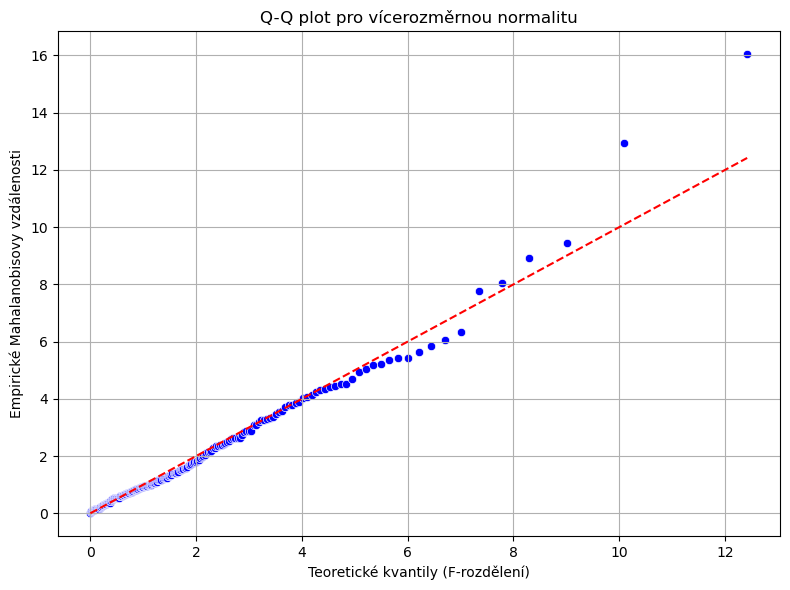

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2,f
# Vykreslení Q-Q plotu
plt.figure(figsize=(8,6))

# Seřazení vzdáleností
df_sorted = df.sort_values("Mahalanobis")
n = len(df_sorted) # počet pozorování
p = 2  # počet proměnných 
quantiles_f = chi2.ppf((np.arange(1, n+1) - 0.5) / n, df=p)
quantiles_f = f.ppf((np.arange(1, n+1) - 0.5) / n, dfn=2, dfd=n-2) * (n-1)*2/(n-2)
sns.scatterplot(x=quantiles_f, y=df_sorted["Mahalanobis"], color="blue")


plt.plot([min(quantiles_f), max(quantiles_f)], [min(quantiles_f), max(quantiles_f)], 'r--')
plt.xlabel("Teoretické kvantily (F-rozdělení)")
plt.ylabel("Empirické Mahalanobisovy vzdálenosti")
plt.title("Q-Q plot pro vícerozměrnou normalitu")
plt.grid(True)
plt.tight_layout()
plt.show()
